In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import pingouin as pg
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
import math
import seaborn as sns
from scipy.optimize import curve_fit
import pyreadr

### Read input data ###

In [10]:
## read hGWAS information 
wdir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/hGWAS/'
df_human_gwas_cat = pd.read_csv(wdir+'gwas_catalog_v1.0.2-associations_e114_r2025-05-13.tsv',
                sep='\t')
#exclude gwas results of interactions between SNPs
df_human_gwas_cat = df_human_gwas_cat.loc[~df_human_gwas_cat['CHR_POS'].astype('str').str.contains ('x')]
#exclude gwas results of haplotypes
df_human_gwas_cat = df_human_gwas_cat.loc[~df_human_gwas_cat['CHR_POS'].astype('str').str.contains (';')]
df_human_gwas_cat = df_human_gwas_cat.dropna(subset=['CHR_POS'])
df_human_gwas_cat.CHR_ID = df_human_gwas_cat.CHR_ID.apply(lambda x: str(int(x)) if type(x)==float else str(x))

/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_28964/1647538912.py:3: DtypeWarning: Columns (9,11,12,13,23,26,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df_human_gwas_cat = pd.read_csv(wdir+'gwas_catalog_v1.0.2-associations_e114_r2025-05-13.tsv',


In [11]:
##read gene coordiantes of DEnpg
wdir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/motif/'
gene_corr = pd.read_csv(wdir+'DEG_human_ortho.txt', sep='\t')
gene_corr.columns = ['human_ens', 'start', 'end', 'human_symbol', 'chr', 'zebrafish_ortho']
gene_corr = gene_corr.loc[gene_corr.human_symbol!='GHR']
gene_corr

,human_ens,start,end,human_symbol,chr,zebrafish_ortho
0,ENSG00000006128,97732084,97740472,TAC1,7,tac1-ENSDARG00000014490
1,ENSG00000069482,68683779,68691175,GAL,11,galn-ENSDARG00000091377
2,ENSG00000116329,28812170,28871267,OPRD1,1,oprd1a-ENSDARG00000041660
3,ENSG00000122585,24284188,24291862,NPY,7,npy-ENSDARG00000036222
4,ENSG00000128564,101162509,101165569,VGF,7,vgf-ENSDARG00000105529
5,ENSG00000131096,43952733,44004469,PYY,17,"pyyb-ENSDARG00000035832,pyya-ENSDARG00000053449"
6,ENSG00000141433,904871,912172,ADCYAP1,18,adcyap1b-ENSDARG00000027740
7,ENSG00000146469,152750797,152759765,VIP,6,vip-ENSDARG00000078247
8,ENSG00000147571,66176376,66178464,CRH,8,crhb-ENSDARG00000027657
9,ENSG00000157005,187668912,187670394,SST,3,sst1.1-ENSDARG00000040799


In [14]:
##import pairs of L1TF-DEnpg derived from zebrafish studies
df_L1TF_DEnpg_pairs  = pyreadr.read_r('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/motif/DEnpg_motif_pairs.rds')[None]
df_L1TF_DEnpg_pairs['label'] = df_L1TF_DEnpg_pairs['motif'].str.split('.').str[0]+'-'+df_L1TF_DEnpg_pairs['human_symbol']
df_L1TF_DEnpg_pairs = df_L1TF_DEnpg_pairs.merge(gene_corr[['human_ens', 'start', 'end', 'chr']], on='human_ens')
df_L1TF_DEnpg_pairs

,zebrafish_ens,gene,motif,human_ens,human_symbol,label,start,end,chr
0,ENSDARG00000014490,tac1-ENSDARG00000014490,MA0488.1,ENSG00000006128,TAC1,MA0488-TAC1,97732084,97740472,7
1,ENSDARG00000014490,tac1-ENSDARG00000014490,MA1132.1,ENSG00000006128,TAC1,MA1132-TAC1,97732084,97740472,7
2,ENSDARG00000014490,tac1-ENSDARG00000014490,MA0099.3,ENSG00000006128,TAC1,MA0099-TAC1,97732084,97740472,7
3,ENSDARG00000014490,tac1-ENSDARG00000014490,MA0462.2,ENSG00000006128,TAC1,MA0462-TAC1,97732084,97740472,7
4,ENSDARG00000014490,tac1-ENSDARG00000014490,MA0489.2,ENSG00000006128,TAC1,MA0489-TAC1,97732084,97740472,7
...,...,...,...,...,...,...,...,...,...
240,ENSDARG00000105529,vgf-ENSDARG00000105529,MA1132.1,ENSG00000128564,VGF,MA1132-VGF,101162509,101165569,7
241,ENSDARG00000105529,vgf-ENSDARG00000105529,MA0462.2,ENSG00000128564,VGF,MA0462-VGF,101162509,101165569,7
242,ENSDARG00000105529,vgf-ENSDARG00000105529,MA0489.2,ENSG00000128564,VGF,MA0489-VGF,101162509,101165569,7
243,ENSDARG00000105529,vgf-ENSDARG00000105529,MA0117.2,ENSG00000128564,VGF,MA0117-VGF,101162509,101165569,7


In [4]:
##read eQTL data
df_human_ortho = pd.read_excel('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/ZebrafishGenomeAnnotation/ortho_genes_20250227.xlsx',
                            sheet_name=0)

wdir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/GTEx/V10/'
## read SNP info for all SNPs used in GTEx
df_gtex_ref = pd.read_csv(wdir+'GTEx_Analysis_2021-02-11_v10_WholeGenomeSeq_953Indiv.lookup_table.txt', sep='\t')
def eQTL_grep(tissue):
    ##import significant eQTL variants with the paired genes
    df_variant_gene = pd.read_parquet(wdir+tissue+'.v10.eQTLs.signif_pairs.parquet')
    ##get rsID for each eQTL vairant
    df_variant_gene = pd.merge(df_variant_gene, df_gtex_ref[['variant_id', 'rs_id_dbSNP155_GRCh38p13']], on='variant_id')
    ##assign gene symbol to each eQTL mapped genes that are orthologues to zebrafish
    df_variant_gene['human_ens'] = df_variant_gene['gene_id'].apply(lambda x: x.split('.')[0])
    df_variant_gene = pd.merge(df_variant_gene, df_human_ortho[['human_symbol', 'human_ens', 'Human Name']], on='human_ens', how='left').dropna()
    ##find eQTL information for human genes orthologous to zebrafish genes genome-wide
    ##add the tissue name to the dataset
    df_variant_gene['tissue']=tissue
    return df_variant_gene

df_eQTL_list = []
for file in os.listdir(wdir):
    if 'eQTLs.signif_pairs.parquet' in file:
        tissue = file.split('.')[0]
        if 'Brain_' in tissue:
            print(tissue)
            df_eQTL_list.append(eQTL_grep(tissue))
df_eQTL = pd.concat(df_eQTL_list)
df_eQTL['chr'] = df_eQTL['variant_id'].str.split('_').str[0]
df_eQTL['pos'] = df_eQTL['variant_id'].str.split('_').str[1].astype(int)
df_eQTL = df_eQTL.drop_duplicates()
df_eQTL = df_eQTL.loc[df_eQTL.rs_id_dbSNP155_GRCh38p13!='.']

Brain_Cerebellar_Hemisphere
Brain_Cortex
Brain_Spinal_cord_cervical_c-1
Brain_Putamen_basal_ganglia
Brain_Amygdala
Brain_Caudate_basal_ganglia
Brain_Nucleus_accumbens_basal_ganglia
Brain_Hypothalamus
Brain_Substantia_nigra
Brain_Cerebellum
Brain_Anterior_cingulate_cortex_BA24
Brain_Hippocampus
Brain_Frontal_Cortex_BA9


In [6]:
##setup color for each disease category
disease_color = {'psychiatric_disorder':"#9656a2", "mental_process":'#369acc',
                 'neurodegenerative_disease':'#95cf92', 'behavior':'#f4895f', 'immune_system_disorder':'#f8e16f',
                'digestive_system_disease':"#de324c",'musculoskeletal':'#6c584c'}

### Analyze GWAS SNPs regarding L1TF-DEnpg Pairs ###

In [25]:
### Within 500kb of each DEnpg, find GWAS SNPs for seven trait categories  
disease_cat = ['psychiatric_disorder','behavior','mental_process','neurodegenerative_disease','immune_system_disorder','digestive_system_disease','musculoskeletal']
df_res = []
for trait_category in disease_cat:
    df_res.append(sigsnp_around_gene(gene_corr.loc[gene_corr.human_symbol.isin(df_L1TF_DEnpg_pairs.human_symbol.unique())], trait_category))
df_res = pd.concat(df_res)
df_res['SNP_ID']=df_res['SNP_ID_CURRENT'].apply(lambda x: 'rs'+str(int(x)))

In [153]:
df_output = df_res.copy()
df_output = df_output.rename(columns = {'target_gene':'DEnpg', 'CHR_ID':'Chr_no', 'CHR_POS':'SNP_pos', 
                            'MAPPED_GENE':'Mapped_gene', 'P-VALUE':'P-value', 'MAPPED_TRAIT':'Mapped_trait', 
                            'MAPPED_TRAIT_URI':'Trait_url', 'PUBMEDID':'PubMed_ID', 'STUDY ACCESSION':'Study_accession', 
                            'trait_category':'Trait_category'})
df_output = df_output[['DEnpg', 'SNP_ID','Chr_no', 'SNP_pos', 'Mapped_gene','P-value', 'Mapped_trait', 'Trait_category','Trait_url', 'PubMed_ID', 'Study_accession']]

output_dir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/submission_2025/Supplementary_tables/'
fn='Table S21 Human GWAS SNPs in TF-DEnpg regulatory network.xlsx'
with pd.ExcelWriter(
        output_dir+fn,
        mode="a",
        engine="openpyxl",
        if_sheet_exists="replace",
    ) as writer:
    df_output.to_excel(writer, sheet_name="All GWAS SNPs around DEnpgs", index=False)

In [ ]:
## Within 500kb of each DEnpg, find TFBSs of the paired L1TF
##one-time computation
##results saved as pickle for quick access
wdir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/motif/JASPAR_motif/'
df_L1TF_DEnpg_motif = []
for motif in df_L1TF_DEnpg_pairs['motif'].str.split('.').str[0].unique():
    for file in os.listdir(wdir):
        if file.startswith(motif):
            df1 = pd.read_csv(wdir+file, sep ='\t', header=None)
            df_temp = df_L1TF_DEnpg_pairs.loc[df_L1TF_DEnpg_pairs['motif'].str.split('.').str[0]==motif]
            df_temp = df_temp[['start', 'end','chr']].apply(lambda x: df1.loc[(df1[0]=='chr'+x['chr'].astype(str))&(df1[1]>=x['start']-500000)&(df1[2]<=x['end']+500000)],axis=1)
            if df_temp.shape[0]>=1:
                df_temp = pd.concat(list(df_temp)).drop_duplicates([0,1,2,6])
                df_temp['motif']=motif
                df_L1TF_DEnpg_motif.append(df_temp)
    
df_L1TF_DEnpg_motif = pd.concat(df_L1TF_DEnpg_motif)
df_L1TF_DEnpg_motif

##save the above results for quick access in the future
import pickle
output_dir='/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/motif/JASPAR_motif/'
with open(output_dir+'df_L1TF_DEnpg_motif_ctecre.pkl', 'wb') as outp:
    pickle.dump(df_L1TF_DEnpg_motif, outp, pickle.HIGHEST_PROTOCOL)

In [1303]:
wdir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/motif/JASPAR_motif/'
df_L1TF_DEnpg_motif = pd.read_pickle(wdir+'df_L1TF_DEnpg_motif.pkl')
df_L1TF_DEnpg_motif.head()

,0,1,2,3,4,5,6,motif
12542104,chr7,97233013,97233023,JUN,872,356,+,MA0488
12542105,chr7,97233233,97233243,JUN,811,279,+,MA0488
12542106,chr7,97233417,97233427,JUN,843,315,-,MA0488
12542107,chr7,97233680,97233690,JUN,833,303,+,MA0488
12542108,chr7,97233954,97233964,JUN,814,282,-,MA0488


In [1305]:
##find TFBS hosting GWAS index SNPs
df_motif_query=df_L1TF_DEnpg_motif.copy()
df_motif_query[1]=df_L1TF_DEnpg_motif[1]+1
df_host_motif = []##find motifs harboring GWAS index SNPs
#see 2.1 for df_res
df_temp = df_res.drop_duplicates(['CHR_ID', 'CHR_POS'])
for i in range(df_temp.shape[0]):
    chr = df_temp.iloc[i]['CHR_ID'] 
    snp_pos = int(df_temp.iloc[i]['CHR_POS'])
    snp_id = df_temp.iloc[i]['SNP_ID']
    df_temp_host = df_motif_query.copy().loc[(df_motif_query[0]=='chr'+chr)&(df_motif_query[1].astype(int)<=snp_pos)&(df_motif_query[2].astype(int)>=snp_pos)]
    if df_temp_host.shape[0]>0:
        df_temp_host['SNP_ID']=snp_id
        df_host_motif.append(df_temp_host)
df_host_motif = pd.concat(df_host_motif)
df_host_motif = df_host_motif.merge(df_res, on='SNP_ID', how='inner')
df_host_motif['label']=df_host_motif['motif']+'-'+df_host_motif['target_gene']
df_host_motif = df_host_motif.loc[df_host_motif['label'].isin(df_L1TF_DEnpg_pairs['label'])]
##add motif id of version 2024
wdir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/motif/JASPAR_motif/'
df_motif_server_filename = pd.read_csv(wdir+'JASPAR_2024_motif_file_name.csv', header=None)
df_host_motif['motif_version_id']=df_host_motif['motif'].apply(lambda x: df_motif_server_filename.loc[df_motif_server_filename[0].str.contains(x)].iloc[0,0].split('.tsv')[0])

##add conservation score of each SNP in the motif
from pyjaspar import jaspardb
jdb_obj = jaspardb(release='JASPAR2024')
df_host_motif['snp_motif_cons']=df_host_motif.apply(lambda x: snp_motif_weight(x['CHR_POS'], x[1], x[2],x[6],x['motif_version_id']),axis=1)

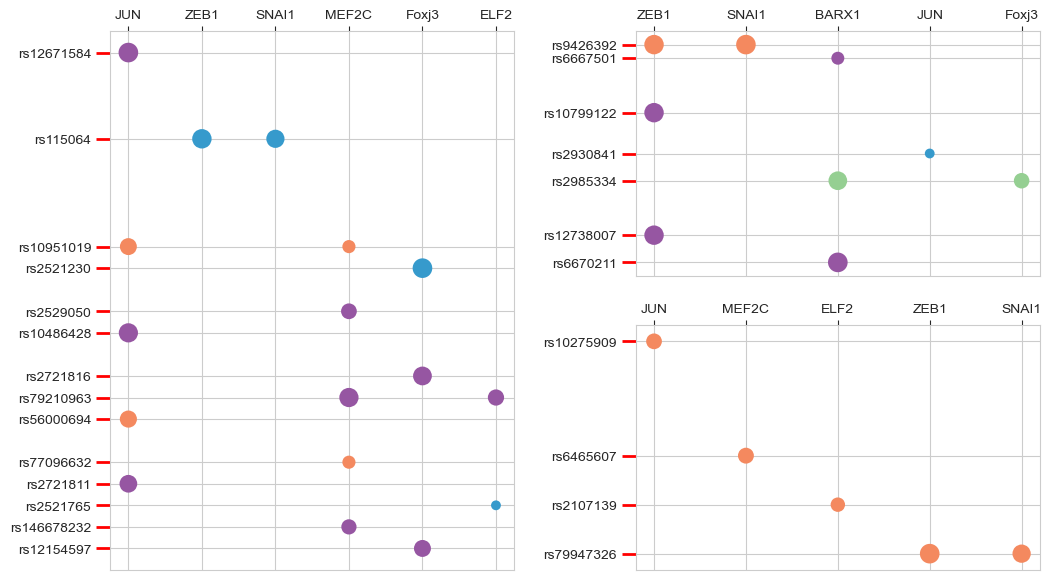

In [1307]:
import matplotlib.gridspec as gridspec
df_plot = df_host_motif.loc[(df_host_motif.target_gene=='NPY')&(df_host_motif.trait_category.isin(['psychiatric_disorder','behavior','mental_process','neurodegenerative_disease']))]
df_plot = df_plot[[3,'SNP_ID','CHR_POS','trait_category', 'snp_motif_cons']]
df_plot[3] = df_plot[3].apply(lambda x: 'JUN' if 'JUN' in x else x)
df_plot = df_plot.drop_duplicates([3,'trait_category','snp_motif_cons','SNP_ID'])
df_plot['CHR_POS'] = df_plot['CHR_POS'].astype(int)
df_plot['plot_pos'] =((df_plot['CHR_POS']-df_plot['CHR_POS'].min())/((df_plot['CHR_POS'].max()-df_plot['CHR_POS'].min())/10)).round()
df_plot['plot_pos'] = df_plot['plot_pos']+df_plot['CHR_POS'].rank(method='dense')
df_plot = df_plot.sort_values([3,'SNP_ID', 'snp_motif_cons'],ascending=False).drop_duplicates([3,'SNP_ID','trait_category'])
df_plot = df_plot.sort_values('plot_pos',ascending=True)
df_plot['color']=df_plot['trait_category'].apply(lambda x: disease_color[x])
#f, ax= plt.subplots(1,1, figsize=(5,4))
fig = plt.figure(figsize=(12,7))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.4)
sns.set_style("whitegrid")
ax1 = fig.add_subplot(gs[:, 0])
g = sns.scatterplot(data=df_plot, x=3, y="plot_pos",size='snp_motif_cons',sizes=(50, 200),hue='color', 
                    palette=list(df_plot['color'].unique()), edgecolor='none',ax=ax1, legend=False)
g.set_yticks(df_plot['plot_pos'].unique())
g.set_ylim(df_plot['plot_pos'].min()-1, df_plot['plot_pos'].max()+1)
g.set_yticklabels(df_plot['SNP_ID'].unique())
g.set_xlabel('')
g.set_ylabel('')
g.tick_params(axis='y', length=10, color='red', left=True, width=2)
g.invert_yaxis()
g.xaxis.set_ticks_position('top')
g.xaxis.set_label_position('top')

df_plot = df_host_motif.loc[(df_host_motif.target_gene=='OPRD1')&(df_host_motif.trait_category.isin(['psychiatric_disorder','behavior','mental_process','neurodegenerative_disease']))]
df_plot = df_plot[[3,'SNP_ID','CHR_POS','trait_category', 'snp_motif_cons']]
df_plot[3] = df_plot[3].apply(lambda x: 'JUN' if 'JUN' in x else x)
df_plot = df_plot.drop_duplicates([3,'trait_category','snp_motif_cons','SNP_ID'])
df_plot['CHR_POS'] = df_plot['CHR_POS'].astype(int)
df_plot['plot_pos'] =((df_plot['CHR_POS']-df_plot['CHR_POS'].min())/((df_plot['CHR_POS'].max()-df_plot['CHR_POS'].min())/10)).round()
df_plot['plot_pos'] = df_plot['plot_pos']+df_plot['CHR_POS'].rank(method='dense')
df_plot = df_plot.sort_values('plot_pos',ascending=True)
df_plot['color']=df_plot['trait_category'].apply(lambda x: disease_color[x])
#f, ax= plt.subplots(1,1, figsize=(5,4))
ax2 = fig.add_subplot(gs[0, 1])
g = sns.scatterplot(data=df_plot, x=3, y="plot_pos",size='snp_motif_cons',sizes=(50, 200),hue='color', 
                    palette=list(df_plot['color'].unique()), edgecolor='none',ax=ax2, legend=False)
g.set_yticks(df_plot['plot_pos'].unique())
g.set_ylim(df_plot['plot_pos'].min()-1, df_plot['plot_pos'].max()+1)
g.set_yticklabels(df_plot['SNP_ID'].unique())
g.set_xlabel('')
g.set_ylabel('')
g.tick_params(axis='y', length=10, color='red', left=True, width=2)
g.invert_yaxis()
g.xaxis.set_ticks_position('top')
g.xaxis.set_label_position('top')

df_plot = df_host_motif.loc[(df_host_motif.target_gene=='TAC1')&(df_host_motif.trait_category.isin(['psychiatric_disorder','behavior','mental_process','neurodegenerative_disease']))]
df_plot = df_plot[[3,'SNP_ID','CHR_POS','trait_category', 'snp_motif_cons']]
df_plot[3] = df_plot[3].apply(lambda x: 'JUN' if (('JUN' in x)|('Jun' in x)) else x)
df_plot = df_plot.drop_duplicates([3,'trait_category','snp_motif_cons','SNP_ID'])
df_plot['CHR_POS'] = df_plot['CHR_POS'].astype(int)
df_plot['plot_pos'] =((df_plot['CHR_POS']-df_plot['CHR_POS'].min())/((df_plot['CHR_POS'].max()-df_plot['CHR_POS'].min())/10)).round()
df_plot['plot_pos'] = df_plot['plot_pos']+df_plot['CHR_POS'].rank(method='dense')
df_plot = df_plot.sort_values('plot_pos',ascending=True)
df_plot['color']=df_plot['trait_category'].apply(lambda x: disease_color[x])
#f, ax= plt.subplots(1,1, figsize=(5,4))
ax3 = fig.add_subplot(gs[1, 1])
g = sns.scatterplot(data=df_plot, x=3, y="plot_pos",size='snp_motif_cons',sizes=(50, 200),hue='color', 
                    palette=list(df_plot['color'].unique()), edgecolor='none',ax=ax3, legend=False)
g.set_yticks(df_plot['plot_pos'].unique())
g.set_ylim(df_plot['plot_pos'].min()-1, df_plot['plot_pos'].max()+1)
g.set_yticklabels(df_plot['SNP_ID'].unique())
g.set_xlabel('')
g.set_ylabel('')
g.tick_params(axis='y', length=10, color='red', left=True, width=2)
g.invert_yaxis()
g.xaxis.set_ticks_position('top')
g.xaxis.set_label_position('top')

gs.update(hspace=0.2, wspace=0.3)
plt.show()

/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_28964/2193813496.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), fontsize=10)
/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_28964/2193813496.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), fontsize=10)
/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_28964/2193813496.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), fontsize=10)
/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_28964/2193813496.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLo

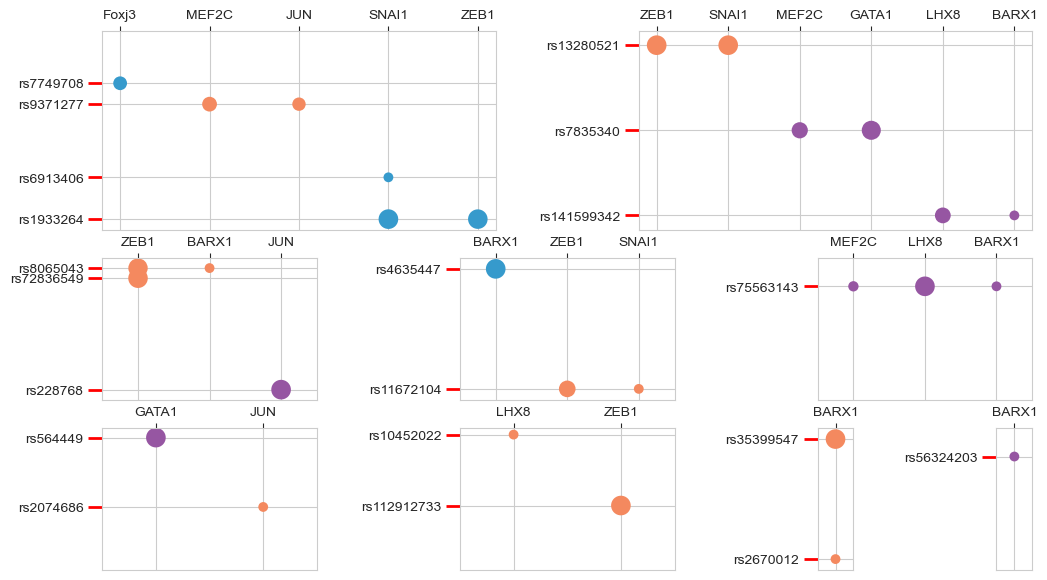

In [1309]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(12,7))
gs = gridspec.GridSpec(10, 6, figure=fig, hspace=1, wspace=4)
sns.set_style("whitegrid")

###VIP###
df_plot = df_host_motif.loc[(df_host_motif.target_gene=='VIP')&(df_host_motif.trait_category.isin(['psychiatric_disorder','behavior','mental_process','neurodegenerative_disease']))]
df_plot = df_plot[[3,'SNP_ID','CHR_POS','trait_category', 'snp_motif_cons']]
df_plot[3] = df_plot[3].apply(lambda x: 'JUN' if 'JUN' in x else x)
df_plot[3] = df_plot[3].apply(lambda x: 'GATA1' if 'GATA1' in x else x)
df_plot[3] = df_plot[3].apply(lambda x: 'LHX8' if 'Lhx8' in x else x)
df_plot = df_plot.drop_duplicates([3,'trait_category','snp_motif_cons','SNP_ID'])
df_plot['CHR_POS'] = df_plot['CHR_POS'].astype(int)
if df_plot['CHR_POS'].unique().shape[0]>=2:
    df_plot['plot_pos'] =((df_plot['CHR_POS']-df_plot['CHR_POS'].min())/((df_plot['CHR_POS'].max()-df_plot['CHR_POS'].min())/10)).round()
    df_plot['plot_pos'] = df_plot['plot_pos']+df_plot['CHR_POS'].rank(method='dense')
else:
    df_plot['plot_pos'] = df_plot['CHR_POS']
df_plot = df_plot.sort_values([3,'SNP_ID', 'snp_motif_cons'],ascending=False).drop_duplicates([3,'SNP_ID','trait_category'])
df_plot = df_plot.sort_values('plot_pos',ascending=True)
df_plot['color']=df_plot['trait_category'].apply(lambda x: disease_color[x])
#f, ax= plt.subplots(1,1, figsize=(5,4))
ax1 = fig.add_subplot(gs[:4, :3])
g = sns.scatterplot(data=df_plot, x=3, y="plot_pos",size='snp_motif_cons',sizes=(50, 200),hue='color', 
                    palette=list(df_plot['color'].unique()), edgecolor='none',ax=ax1, legend=False)
g.set_yticks(df_plot['plot_pos'].unique())
g.set_ylim(df_plot['plot_pos'].min()-5, df_plot['plot_pos'].max()+1)
#g.set_xlim(-0.5,4.5)
g.set_yticklabels(df_plot['SNP_ID'].unique(), fontsize=10)
g.set_xticklabels(g.get_xticklabels(), fontsize=10)
g.set_xlabel('')
g.set_ylabel('')
g.tick_params(axis='y', length=10, color='red', left=True, width=2)
g.invert_yaxis()
g.xaxis.set_ticks_position('top')
g.xaxis.set_label_position('top')


###CRH###
df_plot = df_host_motif.loc[(df_host_motif.target_gene=='CRH')&(df_host_motif.trait_category.isin(['psychiatric_disorder','behavior','mental_process','neurodegenerative_disease']))]
df_plot = df_plot[[3,'SNP_ID','CHR_POS','trait_category', 'snp_motif_cons']]
df_plot[3] = df_plot[3].apply(lambda x: 'JUN' if 'JUN' in x else x)
df_plot[3] = df_plot[3].apply(lambda x: 'GATA1' if 'GATA1' in x else x)
df_plot[3] = df_plot[3].apply(lambda x: 'LHX8' if 'Lhx8' in x else x)
df_plot = df_plot.drop_duplicates([3,'trait_category','snp_motif_cons','SNP_ID'])
df_plot['CHR_POS'] = df_plot['CHR_POS'].astype(int)
if df_plot['CHR_POS'].unique().shape[0]>=2:
    df_plot['plot_pos'] =((df_plot['CHR_POS']-df_plot['CHR_POS'].min())/((df_plot['CHR_POS'].max()-df_plot['CHR_POS'].min())/10)).round()
    df_plot['plot_pos'] = df_plot['plot_pos']+df_plot['CHR_POS'].rank(method='dense')
else:
    df_plot['plot_pos'] = df_plot['CHR_POS']
df_plot = df_plot.sort_values([3,'SNP_ID', 'snp_motif_cons'],ascending=False).drop_duplicates([3,'SNP_ID','trait_category'])
df_plot = df_plot.sort_values('plot_pos',ascending=True)
df_plot['color']=df_plot['trait_category'].apply(lambda x: disease_color[x])
ax1 = fig.add_subplot(gs[:4, 3:])
g = sns.scatterplot(data=df_plot, x=3, y="plot_pos",size='snp_motif_cons',sizes=(50, 200),hue='color', 
                    palette=list(df_plot['color'].unique()), edgecolor='none',ax=ax1, legend=False)
g.set_yticks(df_plot['plot_pos'].unique())
g.set_ylim(df_plot['plot_pos'].min()-1, df_plot['plot_pos'].max()+1)
#g.set_xlim(-0.5,4.5)
g.set_yticklabels(df_plot['SNP_ID'].unique(), fontsize=10)
g.set_xticklabels(g.get_xticklabels(), fontsize=10)
g.set_xlabel('')
g.set_ylabel('')
g.tick_params(axis='y', length=10, color='red', left=True, width=2)
g.invert_yaxis()
g.xaxis.set_ticks_position('top')
g.xaxis.set_label_position('top')

###PYY###
df_plot = df_host_motif.loc[(df_host_motif.target_gene=='PYY')&(df_host_motif.trait_category.isin(['psychiatric_disorder','behavior','mental_process','neurodegenerative_disease']))]
df_plot = df_plot[[3,'SNP_ID','CHR_POS','trait_category', 'snp_motif_cons']]
df_plot[3] = df_plot[3].apply(lambda x: 'JUN' if 'JUN' in x else x)
df_plot[3] = df_plot[3].apply(lambda x: 'GATA1' if 'GATA1' in x else x)
df_plot[3] = df_plot[3].apply(lambda x: 'LHX8' if 'Lhx8' in x else x)
df_plot = df_plot.drop_duplicates([3,'trait_category','snp_motif_cons','SNP_ID'])
df_plot['CHR_POS'] = df_plot['CHR_POS'].astype(int)
if df_plot['CHR_POS'].unique().shape[0]>=2:
    df_plot['plot_pos'] =((df_plot['CHR_POS']-df_plot['CHR_POS'].min())/((df_plot['CHR_POS'].max()-df_plot['CHR_POS'].min())/10)).round()
    df_plot['plot_pos'] = df_plot['plot_pos']+df_plot['CHR_POS'].rank(method='dense')
else:
    df_plot['plot_pos'] = df_plot['CHR_POS']
df_plot = df_plot.sort_values([3,'SNP_ID', 'snp_motif_cons'],ascending=False).drop_duplicates([3,'SNP_ID','trait_category'])
df_plot = df_plot.sort_values('plot_pos',ascending=True)
df_plot['color']=df_plot['trait_category'].apply(lambda x: disease_color[x])
ax1 = fig.add_subplot(gs[4:7, :2])
g = sns.scatterplot(data=df_plot, x=3, y="plot_pos",size='snp_motif_cons',sizes=(50, 200),hue='color', 
                    palette=list(df_plot['color'].unique()), edgecolor='none',ax=ax1, legend=False)
g.set_yticks(df_plot['plot_pos'].unique())
g.set_ylim(df_plot['plot_pos'].min()-1, df_plot['plot_pos'].max()+1)
g.set_xlim(-0.5,2.5)
g.set_yticklabels(df_plot['SNP_ID'].unique(), fontsize=10)
g.set_xticklabels(g.get_xticklabels(), fontsize=10)
g.set_xlabel('')
g.set_ylabel('')
g.tick_params(axis='y', length=10, color='red', left=True, width=2)
g.invert_yaxis()
g.xaxis.set_ticks_position('top')
g.xaxis.set_label_position('top')

###RLN3###
df_plot = df_host_motif.loc[(df_host_motif.target_gene=='RLN3')&(df_host_motif.trait_category.isin(['psychiatric_disorder','behavior','mental_process','neurodegenerative_disease']))]
df_plot = df_plot[[3,'SNP_ID','CHR_POS','trait_category', 'snp_motif_cons']]
df_plot[3] = df_plot[3].apply(lambda x: 'JUN' if 'JUN' in x else x)
df_plot[3] = df_plot[3].apply(lambda x: 'GATA1' if 'GATA1' in x else x)
df_plot[3] = df_plot[3].apply(lambda x: 'LHX8' if 'Lhx8' in x else x)
df_plot = df_plot.drop_duplicates([3,'trait_category','snp_motif_cons','SNP_ID'])
df_plot['CHR_POS'] = df_plot['CHR_POS'].astype(int)
if df_plot['CHR_POS'].unique().shape[0]>=2:
    df_plot['plot_pos'] =((df_plot['CHR_POS']-df_plot['CHR_POS'].min())/((df_plot['CHR_POS'].max()-df_plot['CHR_POS'].min())/10)).round()
    df_plot['plot_pos'] = df_plot['plot_pos']+df_plot['CHR_POS'].rank(method='dense')
else:
    df_plot['plot_pos'] = df_plot['CHR_POS']
df_plot = df_plot.sort_values([3,'SNP_ID', 'snp_motif_cons'],ascending=False).drop_duplicates([3,'SNP_ID','trait_category'])
df_plot = df_plot.sort_values('plot_pos',ascending=True)
df_plot['color']=df_plot['trait_category'].apply(lambda x: disease_color[x])
ax1 = fig.add_subplot(gs[4:7, 2:4])
g = sns.scatterplot(data=df_plot, x=3, y="plot_pos",size='snp_motif_cons',sizes=(50, 200),hue='color', 
                    palette=list(df_plot['color'].unique()), edgecolor='none',ax=ax1, legend=False)
g.set_yticks(df_plot['plot_pos'].unique())
g.set_ylim(df_plot['plot_pos'].min()-1, df_plot['plot_pos'].max()+1)
g.set_xlim(-0.5,2.5)
g.set_yticklabels(df_plot['SNP_ID'].unique(), fontsize=10)
g.set_xticklabels(g.get_xticklabels(), fontsize=10)
g.set_xlabel('')
g.set_ylabel('')
g.tick_params(axis='y', length=10, color='red', left=True, width=2)
g.invert_yaxis()
g.xaxis.set_ticks_position('top')
g.xaxis.set_label_position('top')

###ADCYAP1###
df_plot = df_host_motif.loc[(df_host_motif.target_gene=='ADCYAP1')&(df_host_motif.trait_category.isin(['psychiatric_disorder','behavior','mental_process','neurodegenerative_disease']))]
df_plot = df_plot[[3,'SNP_ID','CHR_POS','trait_category', 'snp_motif_cons']]
df_plot[3] = df_plot[3].apply(lambda x: 'JUN' if 'JUN' in x else x)
df_plot[3] = df_plot[3].apply(lambda x: 'GATA1' if 'GATA1' in x else x)
df_plot[3] = df_plot[3].apply(lambda x: 'LHX8' if 'Lhx8' in x else x)
df_plot = df_plot.drop_duplicates([3,'trait_category','snp_motif_cons','SNP_ID'])
df_plot['CHR_POS'] = df_plot['CHR_POS'].astype(int)
if df_plot['CHR_POS'].unique().shape[0]>=2:
    df_plot['plot_pos'] =((df_plot['CHR_POS']-df_plot['CHR_POS'].min())/((df_plot['CHR_POS'].max()-df_plot['CHR_POS'].min())/10)).round()
    df_plot['plot_pos'] = df_plot['plot_pos']+df_plot['CHR_POS'].rank(method='dense')
else:
    df_plot['plot_pos'] = df_plot['CHR_POS']
df_plot = df_plot.sort_values([3,'SNP_ID', 'snp_motif_cons'],ascending=False).drop_duplicates([3,'SNP_ID','trait_category'])
df_plot = df_plot.sort_values('plot_pos',ascending=True)
df_plot['color']=df_plot['trait_category'].apply(lambda x: disease_color[x])
ax1 = fig.add_subplot(gs[4:7, 4:6])
g = sns.scatterplot(data=df_plot, x=3, y="plot_pos",size='snp_motif_cons',sizes=(50, 200),hue='color', 
                    palette=list(df_plot['color'].unique()), edgecolor='none',ax=ax1, legend=False)
g.set_yticks(df_plot['plot_pos'].unique())
g.set_ylim(df_plot['plot_pos'].min()-1, df_plot['plot_pos'].max()+4)
g.set_xlim(-0.5,2.5)
g.set_yticklabels(df_plot['SNP_ID'].unique(), fontsize=10)
g.set_xticklabels(g.get_xticklabels(), fontsize=10)
g.set_xlabel('')
g.set_ylabel('')
g.tick_params(axis='y', length=10, color='red', left=True, width=2)
g.invert_yaxis()
g.xaxis.set_ticks_position('top')
g.xaxis.set_label_position('top')


###VGF###
df_plot = df_host_motif.loc[(df_host_motif.target_gene=='VGF')&(df_host_motif.trait_category.isin(['psychiatric_disorder','behavior','mental_process','neurodegenerative_disease']))]
df_plot = df_plot[[3,'SNP_ID','CHR_POS','trait_category', 'snp_motif_cons']]
df_plot[3] = df_plot[3].apply(lambda x: 'JUN' if (('JUN' in x)|('Jun' in x)) else x)
df_plot[3] = df_plot[3].apply(lambda x: 'GATA1' if 'GATA1' in x else x)
df_plot = df_plot.drop_duplicates([3,'trait_category','snp_motif_cons','SNP_ID'])
df_plot['CHR_POS'] = df_plot['CHR_POS'].astype(int)
if df_plot['CHR_POS'].unique().shape[0]>=2:
    df_plot['plot_pos'] =((df_plot['CHR_POS']-df_plot['CHR_POS'].min())/((df_plot['CHR_POS'].max()-df_plot['CHR_POS'].min())/10)).round()
    df_plot['plot_pos'] = df_plot['plot_pos']+df_plot['CHR_POS'].rank(method='dense')
else:
    df_plot['plot_pos'] = df_plot['CHR_POS']
df_plot = df_plot.sort_values([3,'SNP_ID', 'snp_motif_cons'],ascending=False).drop_duplicates([3,'SNP_ID','trait_category'])
df_plot = df_plot.sort_values('plot_pos',ascending=True)
df_plot['color']=df_plot['trait_category'].apply(lambda x: disease_color[x])
ax1 = fig.add_subplot(gs[7:10, :2])
g = sns.scatterplot(data=df_plot, x=3, y="plot_pos",size='snp_motif_cons',sizes=(50, 200),hue='color', 
                    palette=list(df_plot['color'].unique()), edgecolor='none',ax=ax1, legend=False)
g.set_yticks(df_plot['plot_pos'].unique())
g.set_ylim(df_plot['plot_pos'].min()-1.5, df_plot['plot_pos'].max()+10)
g.set_xlim(-0.5,1.5)
g.set_yticklabels(df_plot['SNP_ID'].unique(), fontsize=10)
g.set_xticklabels(g.get_xticklabels(), fontsize=10)
g.set_xlabel('')
g.set_ylabel('')
g.tick_params(axis='y', length=10, color='red', left=True, width=2)
g.invert_yaxis()
g.xaxis.set_ticks_position('top')
g.xaxis.set_label_position('top')

###CCK###
df_plot = df_host_motif.loc[(df_host_motif.target_gene=='CCK')&(df_host_motif.trait_category.isin(['psychiatric_disorder','behavior','mental_process','neurodegenerative_disease']))]
df_plot = df_plot[[3,'SNP_ID','CHR_POS','trait_category', 'snp_motif_cons']]
df_plot[3] = df_plot[3].apply(lambda x: 'JUN' if (('JUN' in x)|('Jun' in x)) else x)
df_plot[3] = df_plot[3].apply(lambda x: 'GATA1' if 'GATA1' in x else x)
df_plot[3] = df_plot[3].apply(lambda x: 'LHX8' if 'Lhx8' in x else x)
df_plot = df_plot.drop_duplicates([3,'trait_category','snp_motif_cons','SNP_ID'])
df_plot['CHR_POS'] = df_plot['CHR_POS'].astype(int)
if df_plot['CHR_POS'].unique().shape[0]>=2:
    df_plot['plot_pos'] =((df_plot['CHR_POS']-df_plot['CHR_POS'].min())/((df_plot['CHR_POS'].max()-df_plot['CHR_POS'].min())/10)).round()
    df_plot['plot_pos'] = df_plot['plot_pos']+df_plot['CHR_POS'].rank(method='dense')
else:
    df_plot['plot_pos'] = df_plot['CHR_POS']
df_plot = df_plot.sort_values([3,'SNP_ID', 'snp_motif_cons'],ascending=False).drop_duplicates([3,'SNP_ID','trait_category'])
df_plot = df_plot.sort_values('plot_pos',ascending=True)
df_plot['color']=df_plot['trait_category'].apply(lambda x: disease_color[x])
ax1 = fig.add_subplot(gs[7:10, 2:4])
g = sns.scatterplot(data=df_plot, x=3, y="plot_pos",size='snp_motif_cons',sizes=(50, 200),hue='color', 
                    palette=list(df_plot['color'].unique()), edgecolor='none',ax=ax1, legend=False)
g.set_yticks(df_plot['plot_pos'].unique())
g.set_ylim(df_plot['plot_pos'].min()-1, df_plot['plot_pos'].max()+10)
g.set_xlim(-0.5,1.5)
g.set_yticklabels(df_plot['SNP_ID'].unique(), fontsize=10)
g.set_xticklabels(g.get_xticklabels(), fontsize=10)
g.set_xlabel('')
g.set_ylabel('')
g.tick_params(axis='y', length=10, color='red', left=True, width=2)
g.invert_yaxis()
g.xaxis.set_ticks_position('top')
g.xaxis.set_label_position('top')

###PENK###
df_plot = df_host_motif.loc[(df_host_motif.target_gene=='PENK')&(df_host_motif.trait_category.isin(['psychiatric_disorder','behavior','mental_process','neurodegenerative_disease']))]
df_plot = df_plot[[3,'SNP_ID','CHR_POS','trait_category', 'snp_motif_cons']]
df_plot[3] = df_plot[3].apply(lambda x: 'JUN' if (('JUN' in x)|('Jun' in x)) else x)
df_plot[3] = df_plot[3].apply(lambda x: 'GATA1' if 'GATA1' in x else x)
df_plot[3] = df_plot[3].apply(lambda x: 'LHX8' if 'Lhx8' in x else x)
df_plot = df_plot.drop_duplicates([3,'trait_category','snp_motif_cons','SNP_ID'])
df_plot['CHR_POS'] = df_plot['CHR_POS'].astype(int)
if df_plot['CHR_POS'].unique().shape[0]>=2:
    df_plot['plot_pos'] =((df_plot['CHR_POS']-df_plot['CHR_POS'].min())/((df_plot['CHR_POS'].max()-df_plot['CHR_POS'].min())/10)).round()
    df_plot['plot_pos'] = df_plot['plot_pos']+df_plot['CHR_POS'].rank(method='dense')
else:
    df_plot['plot_pos'] = df_plot['CHR_POS']
df_plot = df_plot.sort_values([3,'SNP_ID', 'snp_motif_cons'],ascending=False).drop_duplicates([3,'SNP_ID','trait_category'])
df_plot = df_plot.sort_values('plot_pos',ascending=True)
df_plot['color']=df_plot['trait_category'].apply(lambda x: disease_color[x])
ax1 = fig.add_subplot(gs[7:10, 4])
g = sns.scatterplot(data=df_plot, x=3, y="plot_pos",size='snp_motif_cons',sizes=(50, 200),hue='color', 
                    palette=list(df_plot['color'].unique()), edgecolor='none',ax=ax1, legend=False)
g.set_yticks(df_plot['plot_pos'].unique())
g.set_ylim(df_plot['plot_pos'].min()-1, df_plot['plot_pos'].max()+1)
g.set_xlim(-0.6,0.6)
g.set_yticklabels(df_plot['SNP_ID'].unique(), fontsize=10)
g.set_xticklabels(g.get_xticklabels(), fontsize=10)
g.set_xlabel('')
g.set_ylabel('')
g.tick_params(axis='y', length=10, color='red', left=True, width=2)
g.invert_yaxis()
g.xaxis.set_ticks_position('top')
g.xaxis.set_label_position('top')

###PENK###
df_plot = df_host_motif.loc[(df_host_motif.target_gene=='NPB')&(df_host_motif.trait_category.isin(['psychiatric_disorder','behavior','mental_process','neurodegenerative_disease']))]
df_plot = df_plot[[3,'SNP_ID','CHR_POS','trait_category', 'snp_motif_cons']]
df_plot[3] = df_plot[3].apply(lambda x: 'JUN' if (('JUN' in x)|('Jun' in x)) else x)
df_plot[3] = df_plot[3].apply(lambda x: 'GATA1' if 'GATA1' in x else x)
df_plot[3] = df_plot[3].apply(lambda x: 'LHX8' if 'Lhx8' in x else x)
df_plot = df_plot.drop_duplicates([3,'trait_category','snp_motif_cons','SNP_ID'])
df_plot['CHR_POS'] = df_plot['CHR_POS'].astype(int)
if df_plot['CHR_POS'].unique().shape[0]>=2:
    df_plot['plot_pos'] =((df_plot['CHR_POS']-df_plot['CHR_POS'].min())/((df_plot['CHR_POS'].max()-df_plot['CHR_POS'].min())/10)).round()
    df_plot['plot_pos'] = df_plot['plot_pos']+df_plot['CHR_POS'].rank(method='dense')
else:
    df_plot['plot_pos'] = df_plot['CHR_POS']
df_plot = df_plot.sort_values([3,'SNP_ID', 'snp_motif_cons'],ascending=False).drop_duplicates([3,'SNP_ID','trait_category'])
df_plot = df_plot.sort_values('plot_pos',ascending=True)
df_plot['color']=df_plot['trait_category'].apply(lambda x: disease_color[x])
ax1 = fig.add_subplot(gs[7:10, 5:])
g = sns.scatterplot(data=df_plot, x=3, y="plot_pos",size='snp_motif_cons',sizes=(50, 200),hue='color', 
                    palette=list(df_plot['color'].unique()), edgecolor='none',ax=ax1, legend=False)
g.set_yticks(df_plot['plot_pos'].unique())
g.set_ylim(df_plot['plot_pos'].min()-1, df_plot['plot_pos'].max()+4)
g.set_xlim(-0.6,0.6)
g.set_yticklabels(df_plot['SNP_ID'].unique(), fontsize=10)
g.set_xticklabels(g.get_xticklabels(), fontsize=10)
g.set_xlabel('')
g.set_ylabel('')
g.tick_params(axis='y', length=10, color='red', left=True, width=2)
g.invert_yaxis()
g.xaxis.set_ticks_position('top')
g.xaxis.set_label_position('top')

plt.show()

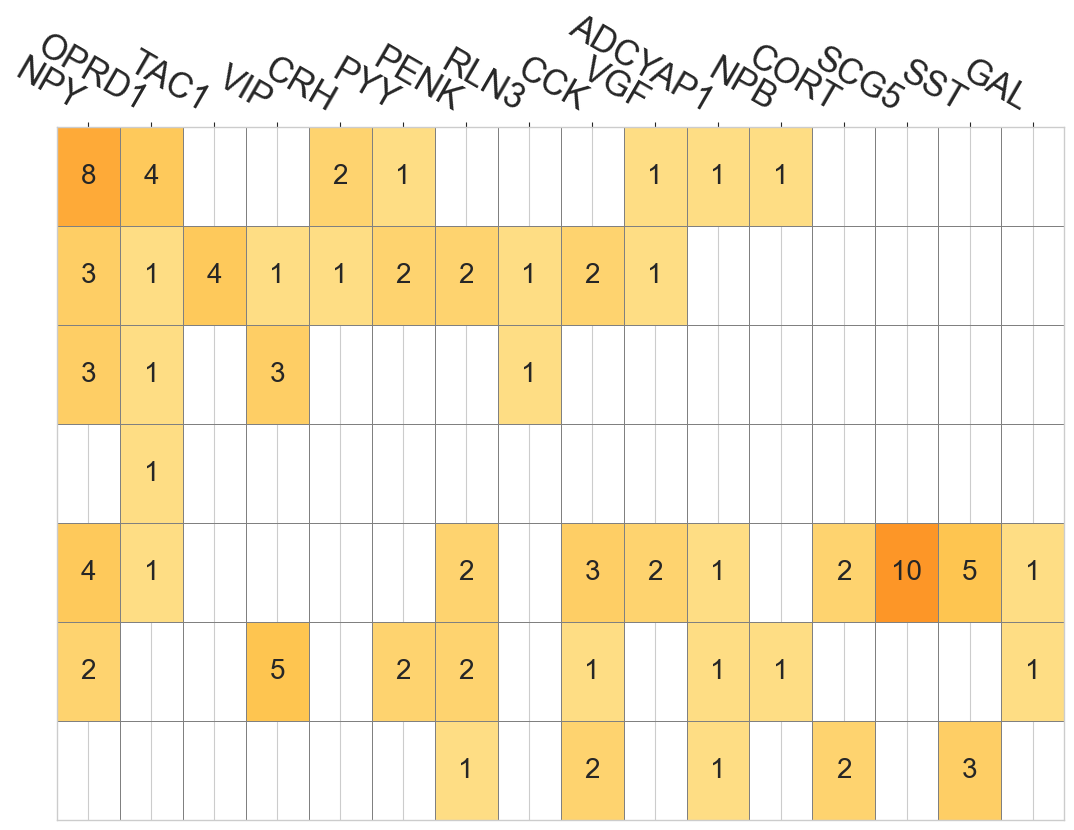

In [1311]:
### heatmap of SNP no. of each HiTF x hcTF pair
df_count = pd.DataFrame(index = df_comp.index, columns = df_L1TF_DEnpg_pairs.human_symbol.unique())
df_temp = df_host_motif.copy()
counts=[]
for cat in df_temp['trait_category'].unique():
    for gene in df_L1TF_DEnpg_pairs.human_symbol.unique():
        df_count.loc[cat, gene]=len(df_temp.loc[(df_temp.trait_category==cat)&(df_temp.target_gene==gene)].SNP_ID.unique())
category_order = df_count.iloc[:4,].sum(axis=1).sort_values(ascending=False).index.to_list()+df_count.iloc[4:,].sum(axis=1).sort_values(ascending=False).index.to_list()
df_count = df_count.loc[category_order,df_count.iloc[:4,].sum().sort_values(ascending=False).index]
df_count = df_count.loc[:,df_count.sum()>0]

f, ax = plt.subplots(1,1,figsize=(13,9))
plt.subplots_adjust(wspace=0.02, hspace=0.02)

colormap = sns.color_palette("YlOrBr", n_colors=50).as_hex()

g = sns.heatmap(df_count.astype(int),cmap=sns.color_palette(palette=colormap, as_cmap=True),vmin = 0, vmax=30,linewidths=0.5, 
                cbar=False, mask=abs(df_count)==0,center = 10,linecolor='grey',ax=ax,yticklabels=False, 
                annot=True, annot_kws={'size':20})
g.set_yticklabels(g.get_yticklabels(),fontsize=18, rotation=0)
g.set_xticklabels(g.get_xticklabels(),fontsize=25, rotation=330,ha='right')
g.set_xlabel("")
g.set_facecolor('white')
g.xaxis.tick_top()
for _, spine in g.spines.items(): 
    spine.set_visible(True) 
    spine.set_linewidth(1)
plt.show()

/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_28964/2498975071.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g=sns.barplot(df_plot['query_pos'], orient='y',palette = colors, ax=ax)


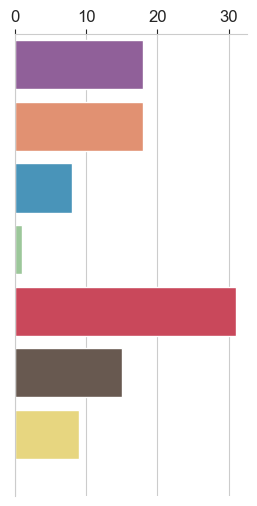

In [1313]:
df_plot = df_comp.copy()
category_order = df_count.iloc[:4,].sum(axis=1).sort_values(ascending=False).index.to_list()+df_count.iloc[4:,].sum(axis=1).sort_values(ascending=False).index.to_list()
df_plot = df_plot.loc[category_order]
f, ax = plt.subplots(1,1, figsize=(3,6))
colors = [disease_color[cat] for cat in category_order]
g=sns.barplot(df_plot['query_pos'], orient='y',palette = colors, ax=ax)
g.set_yticklabels('')
g.set_xlabel('')
g.set_xticks(np.arange(0,35,10))
g.set_xticklabels(np.arange(0,35,10), fontsize=12)
g.set_facecolor('white')
g.xaxis.tick_top()
g.spines['top'].set_visible(True)
g.spines['bottom'].set_visible(False)
g.spines['right'].set_visible(False)
g.set_yticks('')
plt.show()

In [139]:
df_output = df_host_motif.copy()
df_output['Motif_start'] = df_output[[1,2,6]].apply(lambda x: x[1] if x[6]=='+' else x[2], axis=1)
df_output['Motif_end'] = df_output[[1,2,6]].apply(lambda x: x[2] if x[6]=='+' else x[1], axis=1)
df_output = df_output.rename(columns = {0:'Chr_no', 3:'TF_name', 6:'Strand', 'target_gene':'DEnpg', 'CHR_POS':'SNP_pos',
                            'MAPPED_GENE':'Mapped_gene','MAPPED_TRAIT':'Mapped_trait', 'MAPPED_TRAIT_URI':'Trait_url',
                           'PUBMEDID':'PubMed_ID', 'STUDY ACCESSION':'Study_accession', 'trait_category':'Trait_category',
                           'motif_version_id':'Motif_ID', 'P-VALUE':'P-value'})
df_output = df_output[['DEnpg', 'Chr_no', 'Motif_start', 'Motif_end', 'Motif_ID', 
           'TF_name', 'Strand', 'SNP_ID', 'SNP_pos','P-value','Mapped_gene', 
           'Mapped_trait', 'Trait_category','Trait_url','PubMed_ID', 'Study_accession']]

output_dir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/submission_2025/Supplementary_tables/'
fn='Table S21 Human GWAS SNPs in TF-DEnpg regulatory network.xlsx'
with pd.ExcelWriter(
        output_dir+fn,
        mode="a",
        engine="openpyxl",
        if_sheet_exists="replace",
    ) as writer:
    df_output.to_excel(writer, sheet_name="SNPs of TF-DEnpgs", index=False)

In [31]:
### count SNPs in host motifs for each category (query_pos) and across the categories (query_total)
counts=[]
for cat in df_host_motif['trait_category'].unique():
    #for each disease category
    #count all SNPs captured by all TFBSs of L2TF motif around the related L1TF genes in human genome
    counts.append(len(df_host_motif.loc[df_host_motif['trait_category']==cat].SNP_ID.unique()))
df_query_count = pd.Series(counts, index=df_host_motif['trait_category'].unique())
#count the total SNP as the query total
query_snp_total = len(df_host_motif['SNP_ID'].unique())

### count SNPs genome-wide for each category (bg_pos)
bg_counts = []
for cat in df_host_motif['trait_category'].unique():
    pyd = pd.read_excel('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/hGWAS/GWAS_traits_categorization_20251203.xlsx',
                           header=None, sheet_name=cat)
    bg_counts.append(len(df_human_gwas_cat.loc[df_human_gwas_cat.MAPPED_TRAIT.isin(pyd[0])][['CHR_ID','CHR_POS']].apply(lambda x: str(x['CHR_ID'])+'-'+str(int(x['CHR_POS'])),axis=1).unique()))
bg_counts = pd.Series(bg_counts, index = df_host_motif['trait_category'].unique())

### count the total SNP numbers across the seven trait categories (bg_total)
traits = []
for cat in df_host_motif['trait_category'].unique():
    pyd = pd.read_excel('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/hGWAS/GWAS_traits_categorization_20251203.xlsx',
                           header=None, sheet_name=cat)
    traits+=list(pyd[0])
df_bg = df_human_gwas_cat[df_human_gwas_cat.MAPPED_TRAIT.isin(traits)]
bg_snp_total = len(df_bg[['CHR_ID','CHR_POS']].apply(lambda x: str(x['CHR_ID'])+'-'+str(int(x['CHR_POS'])),axis=1).unique())

### perform fisher exact test for each trait category
df_comp = pd.concat([df_query_count,bg_counts],axis=1)
df_comp.columns = ['query_pos', 'bg_pos']
df_comp['bg_pos'] = df_comp['bg_pos']-df_comp['query_pos']
df_comp['query_neg'] = query_snp_total - df_comp['query_pos']
df_comp['bg_neg'] = bg_snp_total-query_snp_total-df_comp['bg_pos']
df_comp['p_enrich']=df_comp.apply(lambda x:func_fisher(x['query_pos'],x['query_neg'],x['bg_pos'],x['bg_neg'], 'two-sided'),axis=1)
df_comp = df_comp.loc[list(disease_color.keys())]
df_comp

,query_pos,bg_pos,query_neg,bg_neg,p_enrich
psychiatric_disorder,18,13198,78,30962,0.018519
mental_process,8,5297,88,38863,0.344408
neurodegenerative_disease,1,1867,95,42293,0.194470
behavior,18,6092,78,38068,0.180302
immune_system_disorder,9,7012,87,37148,0.092446
digestive_system_disease,31,10112,65,34048,0.037835
musculoskeletal,15,7808,81,36352,0.688539


### Analyze eQTL SNPs regarding L1TF-DEnpg Pairs

In [1315]:
df_eQTL_res = df_eQTL.loc[df_eQTL.human_symbol.isin(gene_corr.human_symbol)].copy()
df_colsnp = df_host_motif.loc[df_host_motif.SNP_ID.isin(df_eQTL_res.rs_id_dbSNP155_GRCh38p13)]
df_colsnp = pd.merge(df_colsnp, df_eQTL_res, left_on='SNP_ID', right_on='rs_id_dbSNP155_GRCh38p13')
df_colsnp = df_colsnp.loc[:,[0,1,2,3,4,5,6,'motif', 'SNP_ID', 'target_gene','CHR_POS', 'MAPPED_GENE', 'P-VALUE','MAPPED_TRAIT', 'trait_category','label', 'snp_motif_cons', 'pval_nominal', 'tissue', 'tss_distance']]
df_colsnp.head()

,0,1,2,3,4,5,6,motif,SNP_ID,target_gene,CHR_POS,MAPPED_GENE,P-VALUE,MAPPED_TRAIT,trait_category,label,snp_motif_cons,pval_nominal,tissue,tss_distance
0,chr1,28842253,28842258,ZEB1,870,276,+,MA0103,rs10799122,OPRD1,28842254.0,OPRD1,4.000000e-08,cannabis dependence,psychiatric_disorder,MA0103-OPRD1,0.988872,1.915526e-05,Brain_Cerebellum,30084
1,chr7,97748761,97748770,ELF2,804,266,+,MA1483,rs2107139,TAC1,97748769.0,TAC1 - ASNS,3.000000e-12,risk-taking behaviour,behavior,MA1483-TAC1,0.710861,6.519175e-06,Brain_Substantia_nigra,16685
2,chr7,97748761,97748770,ELF2,804,266,+,MA1483,rs2107139,TAC1,97748769.0,TAC1 - ASNS,3.000000e-12,risk-taking behaviour,behavior,MA1483-TAC1,0.710861,1.402334e-07,Brain_Cerebellum,16685
3,chr7,97725635,97725645,MEF2C,817,301,+,MA0497,rs6465607,TAC1,97725638.0,RN7SKP104 - TAC1,4.000000e-12,risk-taking behaviour,behavior,MA0497-TAC1,0.772295,4.185894e-06,Brain_Substantia_nigra,-6446
4,chr7,97725635,97725645,MEF2C,817,301,+,MA0497,rs6465607,TAC1,97725638.0,RN7SKP104 - TAC1,4.000000e-12,risk-taking behaviour,behavior,MA0497-TAC1,0.772295,1.864905e-07,Brain_Cerebellum,-6446


In [179]:
df_output = df_eQTL_res.copy()
df_output = df_output.rename(columns ={'rs_id_dbSNP155_GRCh38p13':'SNP_ID', 'chr':'Chr_no',
                                       'pos':'SNP_pos', 'human_symbol':'DEnpg', 'tissue':'Tissue', 
                                       'pval_nominal':'Pval_nominal', 'tss_distance':'Tss_distance'})
df_output = df_output[['SNP_ID', 'Chr_no', 'SNP_pos', 'DEnpg', 'Tissue','Pval_nominal','Tss_distance',]]
output_dir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/submission_2025/Supplementary_tables/'
fn='Table S22 Human GWAS SNPs in TF-DEnpg regulatory network.xlsx'
with pd.ExcelWriter(
        output_dir+fn,
        mode="a",
        engine="openpyxl",
        if_sheet_exists="replace",
    ) as writer:
    df_output.to_excel(writer, sheet_name="eQTL SNPs around DEnpgs", index=False)

In [1317]:
df_eQTL_DEnpg = []
df_temp = df_eQTL_res.drop_duplicates(['rs_id_dbSNP155_GRCh38p13'])
for i in range(df_temp.shape[0]):
    chr_no = df_temp.iloc[i, :]['chr']
    pos = df_temp.iloc[i, :]['pos']
    df_eQTL_host_temp = df_L1TF_DEnpg_motif.copy().loc[(df_L1TF_DEnpg_motif[0]==chr_no)&(df_L1TF_DEnpg_motif[1]<=pos)&(df_L1TF_DEnpg_motif[2]>=pos)]
    if df_eQTL_host_temp.shape[0]>0:
        df_eQTL_host_temp['SNP_ID'] = df_temp.iloc[i, :]['rs_id_dbSNP155_GRCh38p13']
        df_eQTL_DEnpg.append(df_eQTL_host_temp)
    else:
        next
df_eQTL_DEnpg = pd.concat(df_eQTL_DEnpg)
df_eQTL_DEnpg = pd.merge(df_eQTL_DEnpg,df_eQTL_res,left_on='SNP_ID', right_on = 'rs_id_dbSNP155_GRCh38p13')
df_eQTL_DEnpg

,0,1,2,3,4,5,6,motif,SNP_ID,gene_id,...,pval_nominal_threshold,min_pval_nominal,pval_beta,rs_id_dbSNP155_GRCh38p13,human_ens,human_symbol,Human Name,tissue,chr,pos
0,chr1,10424914,10424931,GATA1::TAL1,815,339,-,MA0140,rs34776634,ENSG00000241563.4,...,0.000116,1.331770e-09,5.261280e-06,rs34776634,ENSG00000241563,CORT,cortistatin,Brain_Cerebellar_Hemisphere,chr1,10424919
1,chr1,10424956,10424966,ELF2,808,271,+,MA1483,rs2483679,ENSG00000241563.4,...,0.000116,1.331770e-09,5.261280e-06,rs2483679,ENSG00000241563,CORT,cortistatin,Brain_Cerebellar_Hemisphere,chr1,10424962
2,chr1,10425172,10425178,ZEB1,870,276,-,MA0103,rs490037,ENSG00000241563.4,...,0.000116,1.331770e-09,5.261280e-06,rs490037,ENSG00000241563,CORT,cortistatin,Brain_Cerebellar_Hemisphere,chr1,10425178
3,chr1,10425171,10425178,SNAI1,803,236,+,MA1558,rs490037,ENSG00000241563.4,...,0.000116,1.331770e-09,5.261280e-06,rs490037,ENSG00000241563,CORT,cortistatin,Brain_Cerebellar_Hemisphere,chr1,10425178
4,chr1,10425252,10425263,Mafb,862,353,+,MA0117,rs667366,ENSG00000241563.4,...,0.000116,1.331770e-09,5.261280e-06,rs667366,ENSG00000241563,CORT,cortistatin,Brain_Cerebellar_Hemisphere,chr1,10425256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1148,chr11,68942354,68942364,ELF2,827,290,+,MA1483,rs57475359,ENSG00000069482.7,...,0.000113,3.611340e-11,2.287380e-07,rs57475359,ENSG00000069482,GAL,galanin and GMAP prepropeptide,Brain_Frontal_Cortex_BA9,chr11,68942364
1149,chr11,68943692,68943702,JUN,802,270,+,MA0488,rs61887157,ENSG00000069482.7,...,0.000113,3.611340e-11,2.287380e-07,rs61887157,ENSG00000069482,GAL,galanin and GMAP prepropeptide,Brain_Frontal_Cortex_BA9,chr11,68943700
1150,chr11,68966742,68966752,JUN,806,273,-,MA0488,rs12291142,ENSG00000069482.7,...,0.000113,3.611340e-11,2.287380e-07,rs12291142,ENSG00000069482,GAL,galanin and GMAP prepropeptide,Brain_Frontal_Cortex_BA9,chr11,68966752
1151,chr11,68966749,68966755,ZEB1,830,240,+,MA0103,rs12291142,ENSG00000069482.7,...,0.000113,3.611340e-11,2.287380e-07,rs12291142,ENSG00000069482,GAL,galanin and GMAP prepropeptide,Brain_Frontal_Cortex_BA9,chr11,68966752


In [205]:
df_output = df_eQTL_DEnpg.copy()
df_output['Motif_start'] = df_output[[1,2,6]].apply(lambda x: x[1] if x[6]=='+' else x[2], axis=1)
df_output['Motif_end'] = df_output[[1,2,6]].apply(lambda x: x[2] if x[6]=='+' else x[1], axis=1)
df_output = df_output.rename(columns = {0:'Chr_no', 3:'TF_name', 6:'Strand','motif':'Motif_id',
                            'pos':'SNP_pos', 'human_symbol':'DEnpg', 'tissue':'Tissue', 
                            'pval_nominal':'Pval_nominal', 'tss_distance':'Tss_distance'})
df_output= df_output[['SNP_ID','TF_name','Motif_id','Motif_start','Motif_end','Chr_no', 'SNP_pos', 'DEnpg', 'Tissue','Pval_nominal','Tss_distance',]]
output_dir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/submission_2025/Supplementary_tables/'
fn='Table S21 Human GWAS SNPs in TF-DEnpg regulatory network.xlsx'
with pd.ExcelWriter(
        output_dir+fn,
        mode="a",
        engine="openpyxl",
        if_sheet_exists="replace",
    ) as writer:
    df_output.to_excel(writer, sheet_name="eQTL SNPs in TF-DEnpg pairs", index=False)

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/workbook/child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")


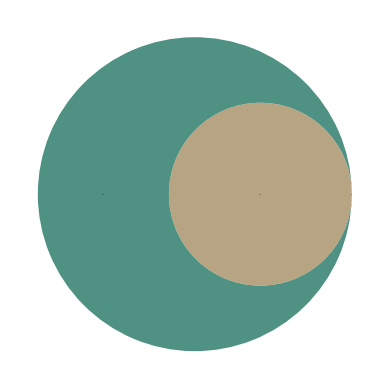

In [1319]:
set2 = set(df_eQTL_DEnpg.rs_id_dbSNP155_GRCh38p13.unique())## eQTLs in paired TFBSs around DEnpgs
set1 = set(df_eQTL_res.rs_id_dbSNP155_GRCh38p13.unique())## all eQTLs around DEnpgs
from matplotlib_venn import venn2
v3=venn2([set1, set2],set_labels=[],set_colors = ["#237764","#c7522a"], alpha=0.8)
for text in v3.subset_labels:  # the text inside the circle
    text.set_fontsize(0)
plt.show()

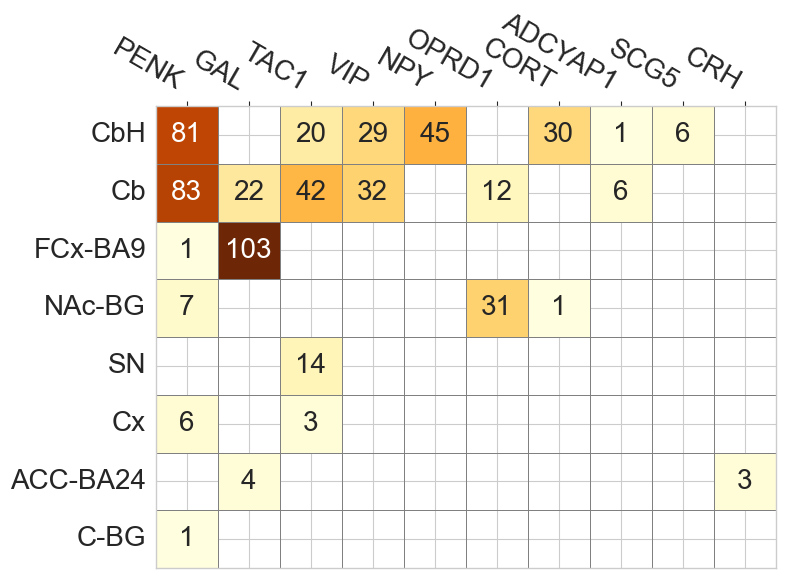

In [1321]:
bts_abbrev = {
    'Brain_Cerebellar_Hemisphere':'CbH',
    'Brain_Cerebellum':'Cb',
    'Brain_Nucleus_accumbens_basal_ganglia':'NAc-BG',
    'Brain_Cortex':'Cx',
    'Brain_Spinal_cord_cervical_c-1':'C-Spine-c1',
    'Brain_Substantia_nigra':'SN',
    'Brain_Hippocampus':'HC',
    'Brain_Putamen_basal_ganglia':'Pu-BG',
    'Brain_Caudate_basal_ganglia':'C-BG',
    'Brain_Frontal_Cortex_BA9':'FCx-BA9',
    'Brain_Anterior_cingulate_cortex_BA24':'ACC-BA24'
}


df_plot = []
for tissue in df_eQTL_DEnpg.tissue.unique():
    df_plot.append(
        df_eQTL_DEnpg.loc[df_eQTL_DEnpg.tissue==tissue].drop_duplicates(['human_symbol','rs_id_dbSNP155_GRCh38p13']).value_counts('human_symbol')
                     )
df_plot = pd.concat(df_plot, axis=1)
df_plot.columns = df_eQTL_DEnpg.tissue.unique()
df_plot= df_plot.fillna(0)
df_plot = df_plot.astype('int').transpose()
f, ax = plt.subplots(1,1, figsize=(8,6))
colormap = sns.color_palette("YlOrBr", n_colors=50).as_hex()
df_plot = df_plot.loc[df_plot.sum(axis=1).sort_values(ascending=False).index,df_plot.sum().sort_values(ascending=False).index]
g = sns.heatmap(df_plot,cmap=sns.color_palette(palette=colormap, as_cmap=True),vmin = 0, vmax=df_plot.max().max(),linewidths=0.5, 
                cbar=False, mask=abs(df_plot.iloc[:20,:])==0,linecolor='grey',ax=ax,
                xticklabels=True, yticklabels=True, annot=True,annot_kws={"fontsize": 20}, fmt="g")


#g.set_xlabel("")
g.set_ylabel("")
g.set_facecolor('white')
g.xaxis.tick_top()
#g.set_yticklabels('')
ylabels = [bts_abbrev[full_name] for full_name in list(df_plot.index)]
g.set_yticklabels(ylabels,fontsize=20, rotation=0)
g.set_xlabel('')
g.set_xticklabels(g.get_xticklabels(),fontsize=20, rotation=330,ha='right')
for _, spine in g.spines.items(): 
    spine.set_visible(True) 
    spine.set_linewidth(1)
plt.show()

### Functions ###

In [19]:
def sigsnp_around_gene(gene_corr, trait_category):
    ##function: find GWAS significant SNPs +/- 500kb from each gene from a gene list for traits belonging to a certain category
    ##gene_corr: dataframe with coordinates of a gene list of interest
    res = []
    for target_gene in gene_corr['human_symbol'].unique():
        pyd = pd.read_excel('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/hGWAS/GWAS_traits_categorization_20251203.xlsx',
                           header=None, sheet_name=trait_category)
        gene_chr = gene_corr.loc[gene_corr['human_symbol']==target_gene, 'chr'].iloc[0]
        gene_start = gene_corr.loc[gene_corr['human_symbol']==target_gene, 'start'].iloc[0]
        gene_end = gene_corr.loc[gene_corr['human_symbol']==target_gene, 'end'].iloc[0]
        df_temp = df_human_gwas_cat.loc[(df_human_gwas_cat['CHR_ID']==str(gene_chr))&(df_human_gwas_cat['CHR_POS'].astype('int')>=gene_start-500000)&(df_human_gwas_cat['CHR_POS'].astype('int')<=gene_end+500000)]
        df_temp = df_temp.loc[df_temp.MAPPED_TRAIT.isin(pyd[0])]
        if df_temp.shape[0]>0:
            df_temp['target_gene']=target_gene
            res.append(df_temp)
    df_res = pd.concat(res)[['target_gene','CHR_ID', 'CHR_POS','MAPPED_GENE','SNP_ID_CURRENT','P-VALUE','MAPPED_TRAIT','MAPPED_TRAIT_URI','PUBMEDID','STUDY ACCESSION']]
    df_res['trait_category'] = trait_category
    return df_res

In [21]:
def snp_motif_weight(snp_pos, motif_start, motif_end, strand, motif_version_id):
    from pyjaspar import jaspardb
    jdb_obj = jaspardb(release='JASPAR2024')
    temp_motif = jdb_obj.fetch_motif_by_id(motif_version_id)
    df_pwm = pd.DataFrame(temp_motif.counts)
    df_cons = df_pwm.div(df_pwm.sum(axis=1), axis=0).max(axis=1)
    if strand == '+':
        pos = int(snp_pos)-motif_start
        
    else:
        pos = motif_end-int(snp_pos)
    return df_cons.iloc[pos]

In [23]:
from scipy.stats import fisher_exact
def func_fisher(query_pos, query_neg, bg_pos, bg_neg, alternative):
    table = np.array([[query_pos,query_neg], [bg_pos, bg_neg]])
    res = fisher_exact(table, alternative=alternative)
    return res[1]

### Permutation test for SNP enrichment analysis in paired TFBS (Depreciated)

In [1057]:
TF_paired_no = []
for gene in df_L1TF_DEnpg_pairs.gene.unique():
    count_temp = df_L1TF_DEnpg_pairs.loc[df_L1TF_DEnpg_pairs.gene==gene].motif.unique().shape[0]
    TF_paired_no.append(count_temp)
TF_paired_no = pd.Series(TF_paired_no, index=df_L1TF_DEnpg_pairs.gene.unique())

In [1173]:
import random
wdir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/motif/JASPAR_motif/'
TFBS_files = [file for file in os.listdir(wdir) if 'tsv.gz' in file]
gene = TF_paired_no.index[7]
random_no =TF_paired_no.loc[gene] 
random_counts_all=[]

In [1191]:
def random_tfbs_snp_cap(gene, TFBS_files, random_no):
    temp_TFBS_files = random.choices(TFBS_files, k=random_no)
    df_random_tfbs = []
    for file in temp_TFBS_files:
        df1 = pd.read_csv(wdir+file, sep ='\t', header=None)
        df1 = df1.loc[df1[0]=='chr7']
        #df_temp = df_L1TF_DEnpg_pairs.loc[df_L1TF_DEnpg_pairs.gene==gene]
        gene_start = df_L1TF_DEnpg_pairs.loc[df_L1TF_DEnpg_pairs.gene==gene].start.iloc[0]
        gene_end = df_L1TF_DEnpg_pairs.loc[df_L1TF_DEnpg_pairs.gene==gene].end.iloc[0]
        #df_temp = df_temp[['start', 'end']].apply(lambda x: df1.loc[(df1[1]>=x['start']-500000)&(df1[2]<=x['end']+500000)],axis=1)
        df_temp = df1.loc[(df1[1]>=gene_start-500000)&(df1[2]<=gene_end+500000)]
        if df_temp.shape[0]>=1:
            df_temp = df_temp.drop_duplicates([0,1,2,6])
            df_random_tfbs.append(df_temp)
    df_random_tfbs = pd.concat(df_random_tfbs)
    df_temp = df_res.drop_duplicates(['CHR_ID', 'CHR_POS'])
    df_random_host_motif = []
    for i in range(df_temp.shape[0]):
        chr = df_temp.iloc[i]['CHR_ID'] 
        snp_pos = int(df_temp.iloc[i]['CHR_POS'])
        snp_id = df_temp.iloc[i]['SNP_ID']
        df_temp_host = df_random_tfbs.copy()
        df_temp_host[1] = df_temp_host[1]+1
        df_temp_host = df_temp_host.loc[(df_temp_host[0]=='chr'+chr)&(df_temp_host[1].astype(int)<=snp_pos)&(df_temp_host[2].astype(int)>=snp_pos)]
        if df_temp_host.shape[0]>0:
            df_temp_host['SNP_ID']=snp_id
            df_random_host_motif.append(df_temp_host)
    df_random_host_motif = pd.concat(df_random_host_motif)
    df_random_host_motif = df_random_host_motif.merge(df_res, on='SNP_ID', how='inner')
    df_random_counts = df_random_host_motif.drop_duplicates(['SNP_ID', 'trait_category']).value_counts('trait_category')
    return df_random_counts

for i in range(0,100):
    random_counts_all.append(random_tfbs_snp_cap(gene, TFBS_files, random_no))

Results: <br>Using NPY as an example, the mean number of SNP with 100 permutation rounds is 1.78 for behavior, 7.41 for pyschiatric disorder and 3.34 for mental process. 

In [1123]:
df_random_tfbs = pd.concat(df_random_tfbs)
df_temp = df_res.drop_duplicates(['CHR_ID', 'CHR_POS'])
df_random_host_motif = []
for i in range(df_temp.shape[0]):
    chr = df_temp.iloc[i]['CHR_ID'] 
    snp_pos = int(df_temp.iloc[i]['CHR_POS'])
    snp_id = df_temp.iloc[i]['SNP_ID']
    df_temp_host = df_random_tfbs.copy()
    df_temp_host[1] = df_temp_host[1]+1
    df_temp_host = df_temp_host.loc[(df_temp_host[0]=='chr'+chr)&(df_temp_host[1].astype(int)<=snp_pos)&(df_temp_host[2].astype(int)>=snp_pos)]
    if df_temp_host.shape[0]>0:
        df_temp_host['SNP_ID']=snp_id
        df_random_host_motif.append(df_temp_host)
df_random_host_motif = pd.concat(df_random_host_motif)
df_random_host_motif = df_random_host_motif.merge(df_res, on='SNP_ID', how='inner')
df_random_counts = df_random_host_motif.drop_duplicates(['SNP_ID', 'trait_category']).value_counts('trait_category')

,0,1,2,3,4,5,6,SNP_ID,target_gene,CHR_ID,CHR_POS,MAPPED_GENE,SNP_ID_CURRENT,P-VALUE,MAPPED_TRAIT,MAPPED_TRAIT_URI,PUBMEDID,STUDY ACCESSION,trait_category
0,chr7,97765570,97765577,ZBTB26,802,273,-,rs13245429,TAC1,7,97765574.0,TAC1 - ASNS,13245429,2.000000e-12,smoking cessation,http://www.ebi.ac.uk/efo/EFO_0004319,36477530,GCST90243980,behavior
1,chr7,97765572,97765577,ZNF354C,812,204,+,rs13245429,TAC1,7,97765574.0,TAC1 - ASNS,13245429,2.000000e-12,smoking cessation,http://www.ebi.ac.uk/efo/EFO_0004319,36477530,GCST90243980,behavior
2,chr7,97744352,97744357,GSC2,838,233,+,rs1510303,TAC1,7,97744357.0,TAC1 - ASNS,1510303.0,1.000000e-08,risk-taking behaviour,http://www.ebi.ac.uk/efo/EFO_0008579,36324656,GCST90239693,behavior
3,chr7,97744351,97744357,HOXB1,950,343,+,rs1510303,TAC1,7,97744357.0,TAC1 - ASNS,1510303.0,1.000000e-08,risk-taking behaviour,http://www.ebi.ac.uk/efo/EFO_0008579,36324656,GCST90239693,behavior
4,chr7,97744352,97744358,HOXB1,823,213,-,rs1510303,TAC1,7,97744357.0,TAC1 - ASNS,1510303.0,1.000000e-08,risk-taking behaviour,http://www.ebi.ac.uk/efo/EFO_0008579,36324656,GCST90239693,behavior
5,chr7,97744351,97744357,GBX1,824,231,+,rs1510303,TAC1,7,97744357.0,TAC1 - ASNS,1510303.0,1.000000e-08,risk-taking behaviour,http://www.ebi.ac.uk/efo/EFO_0008579,36324656,GCST90239693,behavior
6,chr7,97744352,97744358,GBX1,960,343,-,rs1510303,TAC1,7,97744357.0,TAC1 - ASNS,1510303.0,1.000000e-08,risk-taking behaviour,http://www.ebi.ac.uk/efo/EFO_0008579,36324656,GCST90239693,behavior
7,chr7,98083517,98083524,ZBTB26,830,299,-,rs7790120,TAC1,7,98083519.0,RN7SL478P - LMTK2,7790120.0,7.000000e-20,smoking initiation,http://www.ebi.ac.uk/efo/EFO_0005670,36477530,GCST90243968,behavior
8,chr7,97748769,97748774,GSC2,817,218,+,rs2107139,TAC1,7,97748769.0,TAC1 - ASNS,2107139.0,3.000000e-12,risk-taking behaviour,http://www.ebi.ac.uk/efo/EFO_0008579,30643258,GCST007325,behavior
9,chr7,97726793,97726799,GBX1,800,216,+,rs13232655,TAC1,7,97726799.0,RN7SKP104 - TAC1,13232655.0,2.000000e-16,smoking cessation,http://www.ebi.ac.uk/efo/EFO_0004319,36477530,GCST90243988,behavior


### sceQTL (Depreciated)

In [226]:
wdir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/sceQTL/'
sceQTL = []
for file in os.listdir(wdir):
    sceQTL.append(pd.read_csv(wdir+file, sep='\t'))
sceQTL = pd.concat(sceQTL)
sceQTL = sceQTL.loc[sceQTL['geneName'].isin(gene_corr.human_symbol)]
sceQTL

,geneName,chrom,position,variantId,pValue,beta,se,FDR,QTLtype,cellTypeName,cellState,cellClusterName,studyName
65645,GAL,11,68678434.0,rs2510387,0.000204,0.333519,0.089790,0.031320,Cell-type-specific eQTL,Excitatory Neurons,-,Excitatory neurons,Bryois-2022-Nat. Neurosci
65646,GAL,11,68678676.0,rs2513297,0.000204,0.333519,0.089790,0.031320,Cell-type-specific eQTL,Excitatory Neurons,-,Excitatory neurons,Bryois-2022-Nat. Neurosci
65647,GAL,11,68678956.0,rs2187331,0.000204,0.333519,0.089790,0.031320,Cell-type-specific eQTL,Excitatory Neurons,-,Excitatory neurons,Bryois-2022-Nat. Neurosci
65648,GAL,11,68680425.0,rs2513295,0.000204,0.333519,0.089790,0.031320,Cell-type-specific eQTL,Excitatory Neurons,-,Excitatory neurons,Bryois-2022-Nat. Neurosci
65649,GAL,11,68680590.0,rs2510386,0.000204,0.333519,0.089790,0.031320,Cell-type-specific eQTL,Excitatory Neurons,-,Excitatory neurons,Bryois-2022-Nat. Neurosci
...,...,...,...,...,...,...,...,...,...,...,...,...,...
92473,CCK,3,42673220.0,rs235207,0.000067,-0.176783,0.044347,0.028175,Cell-type-specific eQTL,Inhibitory Neurons,-,Inhibitory neurons,Bryois-2022-Nat. Neurosci
92474,CCK,3,42674628.0,rs339712,0.000092,-0.173786,0.044444,0.035975,Cell-type-specific eQTL,Inhibitory Neurons,-,Inhibitory neurons,Bryois-2022-Nat. Neurosci
92475,CCK,3,42675858.0,rs339711,0.000092,-0.173786,0.044444,0.035975,Cell-type-specific eQTL,Inhibitory Neurons,-,Inhibitory neurons,Bryois-2022-Nat. Neurosci
92476,CCK,3,42682335.0,rs339707,0.000092,-0.173786,0.044444,0.035975,Cell-type-specific eQTL,Inhibitory Neurons,-,Inhibitory neurons,Bryois-2022-Nat. Neurosci


In [250]:
df_motif_query=df_L1TF_DEnpg_motif.copy()
df_motif_query[1]=df_L1TF_DEnpg_motif[1]+1
df_sceQTL_temp = sceQTL.loc[sceQTL.geneName.isin(gene_corr.human_symbol)]
df_sceQTL_host = []
for i in range(df_sceQTL_temp.shape[0]):
    gene = df_sceQTL_temp.geneName.iloc[i]
    chr = 'chr'+str(df_sceQTL_temp.chrom.iloc[i])
    pos= df_sceQTL_temp.position.iloc[i]
    snp_id = df_sceQTL_temp.variantId.iloc[i]
    df_host_temp = df_motif_query.copy().loc[(df_motif_query[0]==chr)&(df_motif_query[1]<=pos)&(df_motif_query[2]>=pos)]
    if df_host_temp.shape[0]>0:
        df_host_temp['snp_id'] = snp_id
        df_sceQTL_host.append(df_host_temp)
df_sceQTL_host = pd.concat(df_sceQTL_host)
df_sceQTL_host = pd.merge(df_sceQTL_host, sceQTL, left_on=['snp_id'], right_on=['variantId'])
df_sceQTL_host['label']=df_sceQTL_host['motif']+'-'+df_sceQTL_host['geneName']
df_sceQTL_host = df_sceQTL_host.loc[df_sceQTL_host['label'].isin(df_L1TF_DEnpg_pairs['label'])]
df_sceQTL_host

,0,1,2,3,4,5,6,motif,snp_id,geneName,...,pValue,beta,se,FDR,QTLtype,cellTypeName,cellState,cellClusterName,studyName,label
0,chr11,68680423,68680428,ZEB1,867,270,+,MA0103,rs2513295,GAL,...,0.000204,0.333519,0.089790,0.031320,Cell-type-specific eQTL,Excitatory Neurons,-,Excitatory neurons,Bryois-2022-Nat. Neurosci,MA0103-GAL
1,chr11,68680423,68680429,SNAI1,884,303,-,MA1558,rs2513295,GAL,...,0.000204,0.333519,0.089790,0.031320,Cell-type-specific eQTL,Excitatory Neurons,-,Excitatory neurons,Bryois-2022-Nat. Neurosci,MA1558-GAL
2,chr11,68684501,68684506,ZEB1,893,301,-,MA0103,rs11228324,GAL,...,0.000183,0.317289,0.084809,0.028896,Cell-type-specific eQTL,Excitatory Neurons,-,Excitatory neurons,Bryois-2022-Nat. Neurosci,MA0103-GAL
3,chr11,68684496,68684505,ELF2,831,295,-,MA1483,rs11228324,GAL,...,0.000183,0.317289,0.084809,0.028896,Cell-type-specific eQTL,Excitatory Neurons,-,Excitatory neurons,Bryois-2022-Nat. Neurosci,MA1483-GAL
4,chr18,800079,800089,Mafb,821,304,+,MA0117,rs1275321,ADCYAP1,...,0.000211,0.229455,0.061926,0.032180,Cell-type-specific eQTL,Excitatory Neurons,-,Excitatory neurons,Bryois-2022-Nat. Neurosci,MA0117-ADCYAP1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223,chr3,42675851,42675858,Jun,877,366,-,MA0489,rs339711,CCK,...,0.000092,-0.173786,0.044444,0.035975,Cell-type-specific eQTL,Inhibitory Neurons,-,Inhibitory neurons,Bryois-2022-Nat. Neurosci,MA0489-CCK
224,chr3,42675851,42675859,FOSL1::JUN,849,326,-,MA1128,rs339711,CCK,...,0.000092,-0.173786,0.044444,0.035975,Cell-type-specific eQTL,Inhibitory Neurons,-,Inhibitory neurons,Bryois-2022-Nat. Neurosci,MA1128-CCK
225,chr3,42675851,42675859,FOSL2::JUN,849,317,+,MA1130,rs339711,CCK,...,0.000092,-0.173786,0.044444,0.035975,Cell-type-specific eQTL,Inhibitory Neurons,-,Inhibitory neurons,Bryois-2022-Nat. Neurosci,MA1130-CCK
226,chr3,42675851,42675859,FOSL2::JUN,811,282,-,MA1130,rs339711,CCK,...,0.000092,-0.173786,0.044444,0.035975,Cell-type-specific eQTL,Inhibitory Neurons,-,Inhibitory neurons,Bryois-2022-Nat. Neurosci,MA1130-CCK
